# Qwen2.5-VL PPE Detection — Sample Inference

Notebook version of `infer_sample.py`. Runs inference on a sample image and displays the annotated result inline.

In [ ]:
%%capture
!pip install matplotlib

In [11]:
!fiftyone plugins download https://github.com/Burhan-Q/fiftyone-vllm

   11.6Mb [171.3ms elapsed, ? remaining, 67.4Mb/s] 
Copying plugin '@Burhan-Q/fo-vllm' to '/Users/hasanbadawy/fiftyone/__plugins__/@Burhan-Q/fo-vllm'


In [5]:
import base64
import json
import mimetypes
import os
import re
from pathlib import Path

import requests
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

## Configuration

In [6]:
ENDPOINT = "https://qwen25-vl-7b-instruct-ppe-detection-cv.apps.ocp.9xgvv.sandbox3434.opentlc.com"

NOTEBOOK_DIR = Path.cwd()
SAMPLES_DIR = NOTEBOOK_DIR / "samples"
OUTPUT_DIR = NOTEBOOK_DIR / "output"

IMAGE_NAME = "ppe-01.jpg"  # change to any file in samples/ or a path

LABEL_COLORS = {
    "person": (255, 0, 0),
    "hard_hat": (255, 165, 0),
    "safety_vest": (255, 255, 0),
    "gloves": (0, 255, 255),
    "safety_glasses": (0, 128, 255),
    "mask": (255, 0, 255),
    "boots": (128, 0, 255),
}
DEFAULT_COLOR = (0, 255, 0)

DEFAULT_PROMPT = """Detect every person and every PPE item (person, hard_hat, safety_vest, gloves, safety_glasses, mask, boots) in the image.

Return ONLY valid JSON, no prose, no markdown fences. Use this exact schema:
{
  \"image_size\": {\"width\": <int>, \"height\": <int>},
  \"detections\": [
    {\"label\": \"<class>\", \"bbox_2d\": [x1, y1, x2, y2], \"confidence\": <float 0-1>}
  ]
}
Coordinates must be absolute pixel values in the original image. bbox_2d = [x1, y1, x2, y2] with (x1,y1)=top-left, (x2,y2)=bottom-right."""

## Helper functions

In [7]:
def auth_headers() -> dict:
    token = os.environ.get("VLLM_API_TOKEN") or os.environ.get("OPENAI_API_KEY", "external-token")
    return {"Authorization": f"Bearer {token}"} if token else {}


def encode_image(path: Path) -> str:
    mime = mimetypes.guess_type(path.name)[0] or "image/jpeg"
    b64 = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime};base64,{b64}"


def get_model(base_url: str) -> str:
    r = requests.get(f"{base_url}/v1/models", timeout=30, headers=auth_headers())
    r.raise_for_status()
    return r.json()["data"][0]["id"]


def infer(image_path: Path, prompt: str, base_url: str) -> str:
    model = get_model(base_url)
    payload = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": encode_image(image_path)}},
                ],
            }
        ],
        "max_tokens": 1024,
        "temperature": 0.2,
    }
    r = requests.post(
        f"{base_url}/v1/chat/completions",
        json=payload,
        timeout=180,
        headers={"Content-Type": "application/json", **auth_headers()},
    )
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]


def parse_detections(raw: str) -> dict:
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        raise ValueError("No JSON object found in model output")
    return json.loads(match.group(0))


def draw_detections(image_path: Path, data: dict, out_path: Path) -> Image.Image:
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 14)
    except OSError:
        font = ImageFont.load_default()

    for det in data.get("detections", []):
        label = det.get("label", "?")
        x1, y1, x2, y2 = det["bbox_2d"]
        conf = det.get("confidence", 0.0)
        color = LABEL_COLORS.get(label, DEFAULT_COLOR)
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

        text = f"{label} {conf:.2f}"
        tb = draw.textbbox((0, 0), text, font=font)
        tw, th = tb[2] - tb[0], tb[3] - tb[1]
        ty = max(0, y1 - th - 4)
        draw.rectangle([x1, ty, x1 + tw + 6, ty + th + 4], fill=color)
        draw.text((x1 + 3, ty + 2), text, fill=(0, 0, 0), font=font)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(out_path)
    return img

## Resolve image path

In [8]:
path = Path(IMAGE_NAME)
if not path.is_file():
    path = SAMPLES_DIR / IMAGE_NAME
if not path.is_file():
    raise FileNotFoundError(f"Image not found: {IMAGE_NAME}")

print(f"Image:    {path}")
print(f"Endpoint: {ENDPOINT}")

Image:    /Users/hasanbadawy/Documents/CODE/rhelai-cv-ppe-demo/samples/ppe-01.jpg
Endpoint: https://qwen25-vl-7b-instruct-ppe-detection-cv.apps.ocp.9xgvv.sandbox3434.opentlc.com


## Run inference

In [9]:
raw = infer(path, DEFAULT_PROMPT, ENDPOINT)
print(raw)

```json
{
  "image_size": {
    "width": 640,
    "height": 480
  },
  "detections": [
    {
      "label": "person",
      "bbox_2d": [357, 140, 490, 451],
      "confidence": 0.95
    },
    {
      "label": "person",
      "bbox_2d": [182, 116, 291, 415],
      "confidence": 0.95
    },
    {
      "label": "hard_hat",
      "bbox_2d": [433, 140, 471, 168],
      "confidence": 0.9
    },
    {
      "label": "hard_hat",
      "bbox_2d": [192, 116, 231, 142],
      "confidence": 0.9
    },
    {
      "label": "safety_vest",
      "bbox_2d": [182, 169, 291, 233],
      "confidence": 0.9
    },
    {
      "label": "safety_vest",
      "bbox_2d": [357, 194, 490, 280],
      "confidence": 0.9
    },
    {
      "label": "gloves",
      "bbox_2d": [227, 221, 254, 243],
      "confidence": 0.9
    },
    {
      "label": "gloves",
      "bbox_2d": [385, 199, 410, 221],
      "confidence": 0.9
    },
    {
      "label": "safety_glasses",
      "bbox_2d": [435, 168, 460, 176],
      "conf

## Parse detections and annotate

In [9]:
data = parse_detections(raw)
out_path = OUTPUT_DIR / f"{path.stem}_annotated{path.suffix}"
annotated = draw_detections(path, data, out_path)
print(f"Annotated image saved to: {out_path}")
print(f"Detections: {len(data.get('detections', []))}")

Annotated image saved to: /Users/hasanbadawy/Documents/CODE/rhelai-cv-ppe-demo/output/ppe-01_annotated.jpg
Detections: 10


## Display annotated image

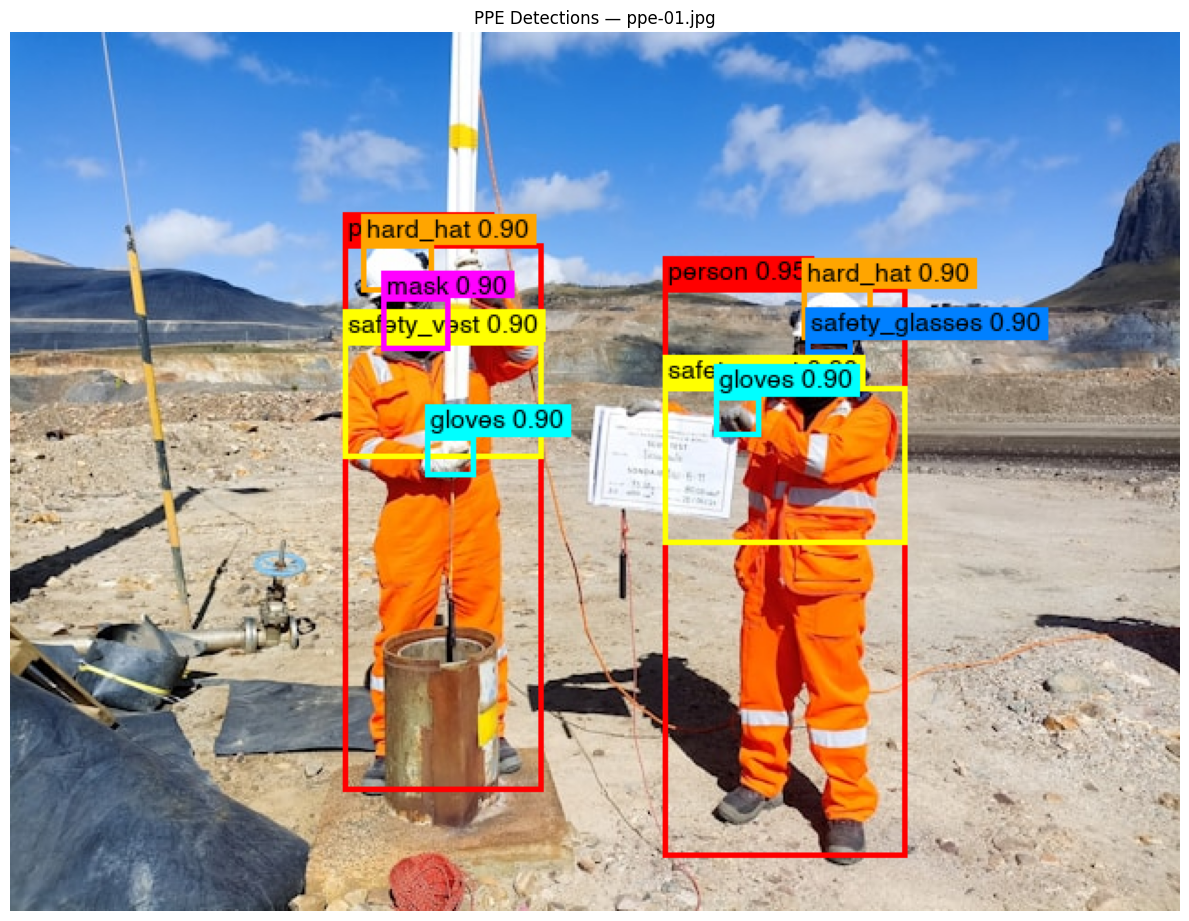

In [10]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(annotated)
ax.set_axis_off()
ax.set_title(f"PPE Detections — {path.name}")
plt.tight_layout()
plt.show()

In [3]:
import fiftyone as fo
fo.close_app()
#dataset = fo.load_dataset("construciton-ppe")
session = fo.launch_app(port=5151, address="0.0.0.0") # , remote=True
session.show()